In [1]:
# ============================================================
# CEREBRAL AUTOREGULATION ANALYSIS
# CPP, PRx, CPPopt ANALYSIS
# ============================================================

# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.optimize import curve_fit

In [2]:
# ============================================================
# SELECT CSV FILE
# ============================================================

print("Select CSV File")

file_path = input("Enter CSV File Path: ")

# ============================================================
# LOAD CSV FILE
# ============================================================

df = pd.read_csv(file_path)

print("\nCSV Loaded Successfully!")

print(df.head())

Select CSV File


Enter CSV File Path:  C:\Users\welcome\Downloads\C11Arvind.csv



CSV Loaded Successfully!
       TTDate Timestamp  MAP  ICP
0  08-12-2016  13:23:38   69    1
1  08-12-2016  13:23:43   68    1
2  08-12-2016  13:23:48   67    2
3  08-12-2016  13:23:53   67    2
4  08-12-2016  13:23:58   68    1


In [3]:
# ============================================================
# COMBINE DATE + TIME
# ============================================================

# Creating proper datetime column with mixed format handling
df['DateTime'] = pd.to_datetime(
    df['TTDate'].astype(str) + ' ' + df['Timestamp'].astype(str),
    format='mixed',  # Added format='mixed' to handle inconsistent formats
    dayfirst=True    # Keep dayfirst=True as suggested in the error message
)

# ============================================================
# SORT DATA BY TIME
# ============================================================

df = df.sort_values('DateTime')

df = df.reset_index(drop=True)

In [4]:
# ============================================================
# DATA CLEANING
# ============================================================

print("Original Data Points:", len(df))

# Remove impossible physiological values

df = df[
    (df['MAP'] >= 40) &
    (df['MAP'] <= 180) &
    (df['ICP'] >= 0) &
    (df['ICP'] <= 50)
]

print("After Physiological Filtering:", len(df))

# ============================================================
# REMOVE EXTREME OUTLIERS USING IQR METHOD
# ============================================================

def remove_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]

df = remove_outliers_iqr(df, 'MAP')
df = remove_outliers_iqr(df, 'ICP')

print("After Outlier Removal:", len(df))

# ============================================================
# CREATE CPP
# ============================================================

df['CPP'] = df['MAP'] - df['ICP']

# ============================================================
# 1-MINUTE MOVING AVERAGE SMOOTHING
# 12 samples × 5 sec = 60 sec
# ============================================================

SMOOTH_WINDOW = 12

df['MAP_smooth'] = (
    df['MAP']
    .rolling(window=SMOOTH_WINDOW,
             center=True)
    .mean()
)

df['ICP_smooth'] = (
    df['ICP']
    .rolling(window=SMOOTH_WINDOW,
             center=True)
    .mean()
)

df['CPP_smooth'] = (
    df['CPP']
    .rolling(window=SMOOTH_WINDOW,
             center=True)
    .mean()
)

# Remove NaN generated by rolling average

df = df.dropna().reset_index(drop=True)

print("After Smoothing:", len(df))

Original Data Points: 14420
After Physiological Filtering: 14417
After Outlier Removal: 12365
After Smoothing: 12354


In [5]:
# ============================================================
# PRx CALCULATION
# ============================================================

from scipy.stats import pearsonr

# ============================================================
# PARAMETERS
# ============================================================

WINDOW_MINUTES = 15

SAMPLE_INTERVAL = 5      # seconds

WINDOW_SIZE = int((WINDOW_MINUTES * 60) / SAMPLE_INTERVAL)

STEP_SIZE = 12           # 1 minute update

print("Window Size =", WINDOW_SIZE)

# ============================================================
# STORAGE LISTS
# ============================================================

prx_values = []

mean_cpp_values = []

prx_times = []

# ============================================================
# CALCULATE PRx
# ============================================================

for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):

    end = start + WINDOW_SIZE

    window = df.iloc[start:end]

    # ========================================================
    # CHECK FOR DATA GAPS
    # ========================================================

    max_gap = window['DateTime'].diff().max()

    if pd.isna(max_gap):
        continue

    if max_gap > pd.Timedelta(minutes=1):
        continue

    # ========================================================
    # EXTRACT SMOOTHED SIGNALS
    # ========================================================

    map_window = window['MAP_smooth']

    icp_window = window['ICP_smooth']

    cpp_window = window['CPP_smooth']

    # ========================================================
    # SKIP IF CONSTANT SIGNAL
    # ========================================================

    if map_window.std() < 0.01:
        continue

    if icp_window.std() < 0.01:
        continue

    # ========================================================
    # PRx = PEARSON CORRELATION
    # ========================================================

    prx, _ = pearsonr(map_window, icp_window)

    # ========================================================
    # MEAN CPP FOR THIS WINDOW
    # ========================================================

    mean_cpp = cpp_window.mean()

    # ========================================================
    # STORE RESULTS
    # ========================================================

    prx_values.append(prx)

    mean_cpp_values.append(mean_cpp)

    prx_times.append(window['DateTime'].iloc[-1])

# ============================================================
# CREATE DATAFRAME
# ============================================================

prx_df = pd.DataFrame({

    'Time': prx_times,

    'Mean_CPP': mean_cpp_values,

    'PRx': prx_values

})

print("\nPRx Calculation Completed")

print("Total PRx Values:", len(prx_df))

print(prx_df.head())

Window Size = 180

PRx Calculation Completed
Total PRx Values: 646
                 Time   Mean_CPP       PRx
0 2016-12-08 14:14:53  71.476852  0.846464
1 2016-12-08 14:15:53  71.667593  0.854101
2 2016-12-08 14:16:53  71.766667  0.911828
3 2016-12-08 14:17:53  71.755093  0.895863
4 2016-12-08 14:18:53  71.893519  0.882163


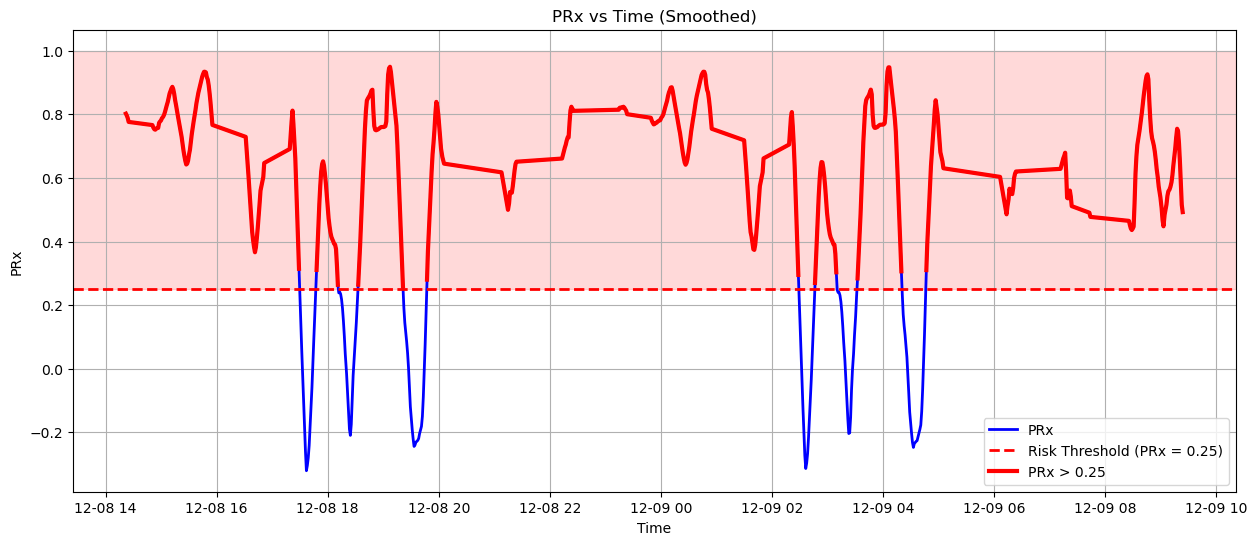

In [6]:
import matplotlib.pyplot as plt

prx_df['PRx_Smooth'] = (
    prx_df['PRx']
    .rolling(window=15, center=True)
    .mean()
)

plt.figure(figsize=(15,6))

# Plot full PRx trend
plt.plot(
    prx_df['Time'],
    prx_df['PRx_Smooth'],
    linewidth=2,
    color='blue',
    label='PRx'
)

# Risk threshold line
plt.axhline(
    y=0.25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Risk Threshold (PRx = 0.25)'
)

# Highlight values above 0.25 in red
prx_above = prx_df['PRx_Smooth'].where(prx_df['PRx_Smooth'] > 0.25)

plt.plot(
    prx_df['Time'],
    prx_above,
    color='red',
    linewidth=3,
    label='PRx > 0.25'
)

plt.xlabel("Time")
plt.ylabel("PRx")
plt.title("PRx vs Time (Smoothed)")
plt.grid(True)
plt.legend()
plt.axhspan(
    0.25,
    1.0,
    color='red',
    alpha=0.15
)

plt.show()

In [7]:
# ============================================================
# FIND BEST CPPopt WINDOW
# ============================================================
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# ============================================================
# SETTINGS
# ============================================================

WINDOW_SIZE = 240      # 4 hr window (240 PRx values)
STEP_SIZE = 1          # update every minute

best_r2 = -999
best_cppopt = None
best_grouped = None
best_params = None
best_time = None

# ============================================================
# QUADRATIC FUNCTION
# ============================================================

def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

# ============================================================
# LOOP THROUGH WINDOWS
# ============================================================

for start in range(0, len(prx_df)-WINDOW_SIZE):

    end = start + WINDOW_SIZE

    temp_df = prx_df.iloc[start:end].copy()

    # --------------------------------------------------------
    # CPP BINNING
    # --------------------------------------------------------

    bins = np.arange(40, 121, 5)

    temp_df['CPP_Bin'] = pd.cut(
        temp_df['Mean_CPP'],
        bins=bins
    )

    grouped = (
        temp_df
        .groupby('CPP_Bin', observed=False)
        .agg(
            Mean_CPP=('Mean_CPP','mean'),
            Mean_PRx=('PRx','mean'),
            Count=('PRx','count')
        )
        .dropna()
    )

    grouped = grouped[grouped['Count'] >= 5]

    # --------------------------------------------------------
    # NEED SUFFICIENT BINS
    # --------------------------------------------------------

    if len(grouped) < 5:
        continue

    x = grouped['Mean_CPP'].values
    y = grouped['Mean_PRx'].values
    w = grouped['Count'].values

    try:

        params, _ = curve_fit(
            quadratic,
            x,
            y,
            sigma=1/np.sqrt(w),
            absolute_sigma=False
        )

        a, b, c = params

        # ----------------------------------------------------
        # REJECT INVERTED CURVE
        # ----------------------------------------------------

        if a <= 0:
            continue

        cppopt = -b/(2*a)

        # ----------------------------------------------------
        # REJECT OUTSIDE RANGE
        # ----------------------------------------------------

        if cppopt < 40 or cppopt > 120:
            continue

        y_pred = quadratic(x, a, b, c)

        r2 = r2_score(y, y_pred)

        # ----------------------------------------------------
        # REJECT POOR FIT
        # ----------------------------------------------------

        if r2 < 0.20:
            continue

        # ----------------------------------------------------
        # KEEP BEST WINDOW
        # ----------------------------------------------------

        if r2 > best_r2:

            best_r2 = r2
            best_cppopt = cppopt
            best_grouped = grouped.copy()
            best_params = params
            best_time = temp_df['Time'].iloc[-1]

    except:
        continue

# ============================================================
# RESULTS
# ============================================================

print("Best Window Time:", best_time)
print("Best CPPopt:", round(best_cppopt,2))
print("Best R²:", round(best_r2,3))

Best Window Time: 2016-12-09 02:47:33
Best CPPopt: 76.6
Best R²: 0.911


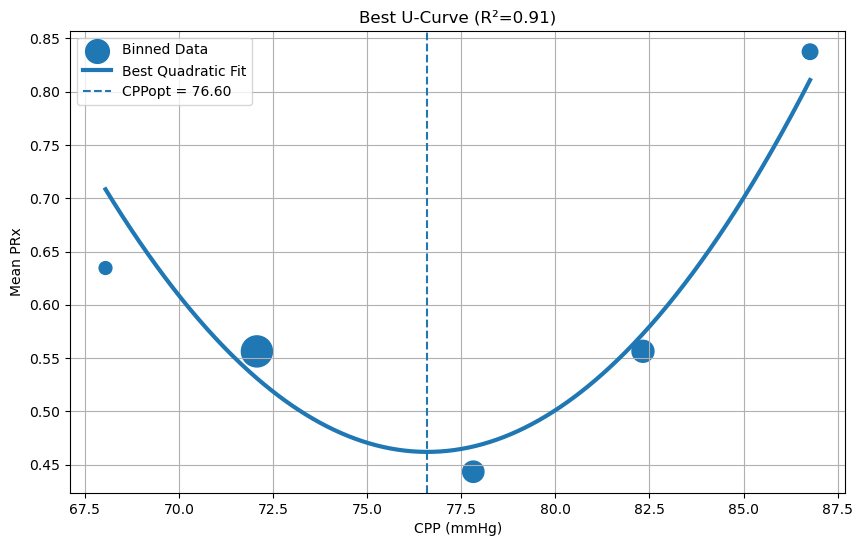

In [20]:
# ============================================================
# PLOT BEST U CURVE
# ============================================================

a,b,c = best_params

x = best_grouped['Mean_CPP'].values
y = best_grouped['Mean_PRx'].values
w = best_grouped['Count'].values

x_fit = np.linspace(min(x), max(x), 500)

y_fit = quadratic(x_fit, a, b, c)

plt.figure(figsize=(10,6))

plt.scatter(
    x,
    y,
    s=w*5,
    label='Binned Data'
)

plt.plot(
    x_fit,
    y_fit,
    linewidth=3,
    label='Best Quadratic Fit'
)

plt.axvline(
    best_cppopt,
    linestyle='--',
    label=f'CPPopt = {best_cppopt:.2f}'
)

plt.xlabel("CPP (mmHg)")
plt.ylabel("Mean PRx")
plt.title(f'Best U-Curve (R²={best_r2:.2f})')

plt.grid(True)
plt.legend()

plt.show()

In [18]:
# ============================================================
# CREATE COMPLETE CPPopt SERIES
# ============================================================

cppopt_all_times = []
cppopt_all_values = []

for start in range(0, len(prx_df)-WINDOW_SIZE, STEP_SIZE):

    end = start + WINDOW_SIZE

    temp_df = prx_df.iloc[start:end].copy()

    current_time = temp_df['Time'].iloc[-1]

    temp_df['CPP_Bin'] = pd.cut(
        temp_df['Mean_CPP'],
        bins=np.arange(40,121,5)
    )

    grouped = (
        temp_df
        .groupby('CPP_Bin', observed=False)
        .agg(
            Mean_CPP=('Mean_CPP','mean'),
            Mean_PRx=('PRx','mean'),
            Count=('PRx','count')
        )
        .dropna()
    )

    grouped = grouped[grouped['Count'] >= 5]

    # --------------------------------------------------------
    # DEFAULT = INVALID WINDOW
    # --------------------------------------------------------

    cppopt_value = np.nan

    try:

        if len(grouped) >= 5:

            x = grouped['Mean_CPP'].values
            y = grouped['Mean_PRx'].values
            w = grouped['Count'].values

            params, _ = curve_fit(
                quadratic,
                x,
                y,
                sigma=1/np.sqrt(w),
                absolute_sigma=False
            )

            a,b,c = params

            cppopt = -b/(2*a)

            y_pred = quadratic(x,a,b,c)

            r2 = r2_score(y,y_pred)

            if (
                a > 0 and
                40 <= cppopt <= 120 and
                r2 >= 0.20
            ):
                cppopt_value = cppopt

    except:
        pass

    cppopt_all_times.append(current_time)
    cppopt_all_values.append(cppopt_value)

# ============================================================
# DATAFRAME
# ============================================================

cppopt_df = pd.DataFrame({

    'Time': cppopt_all_times,
    'CPPopt': cppopt_all_values

})

# ============================================================
# SMOOTH VALID VALUES
# ============================================================

cppopt_df['CPPopt_Smooth'] = (
    cppopt_df['CPPopt']
    .rolling(
        window=15,
        center=True,
        min_periods=1
    )
    .mean()
)

# ============================================================
# REJECTED WINDOWS
# ============================================================

rejected_df = cppopt_df[
    cppopt_df['CPPopt'].isna()
]

# ============================================================
# SUMMARY
# ============================================================

print()

print("Valid CPPopt Windows :",
      cppopt_df['CPPopt'].notna().sum())

print("Rejected Windows     :",
      cppopt_df['CPPopt'].isna().sum())

print()


Valid CPPopt Windows : 305
Rejected Windows     : 101



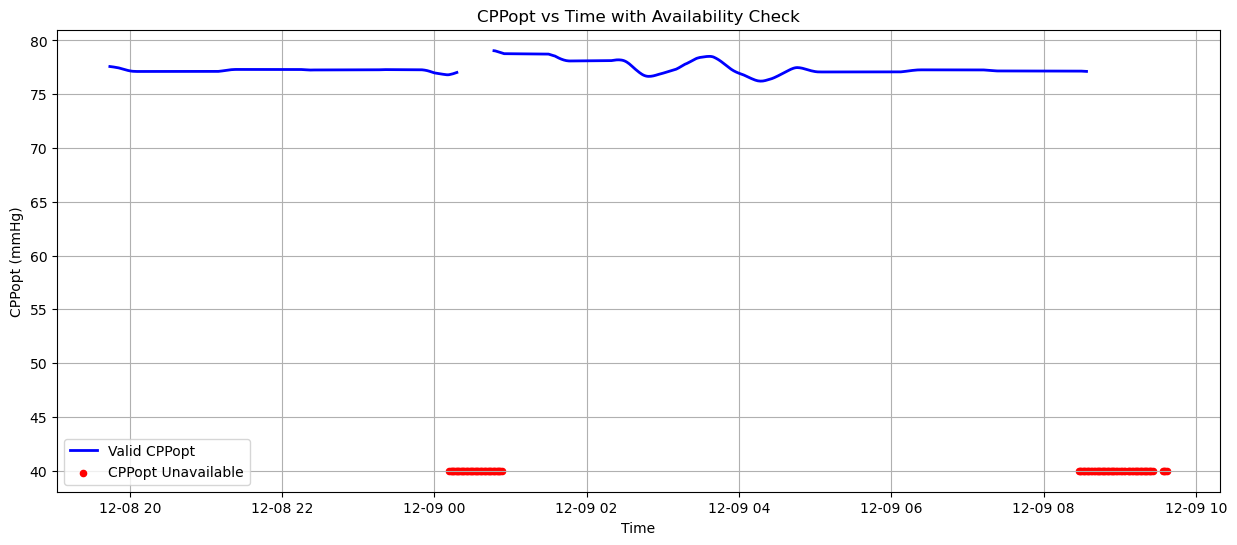

In [19]:
# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(15,6))

# CPPopt line
plt.plot(
    cppopt_df['Time'],
    cppopt_df['CPPopt_Smooth'],
    linewidth=2,
    color='blue',
    label='Valid CPPopt'
)

# Rejected windows
plt.scatter(
    rejected_df['Time'],
    np.full(len(rejected_df),40),
    color='red',
    marker='o',
    s=20,
    label='CPPopt Unavailable'
)

plt.xlabel("Time")
plt.ylabel("CPPopt (mmHg)")
plt.title("CPPopt vs Time with Availability Check")

plt.grid(True)
plt.legend()

plt.show()

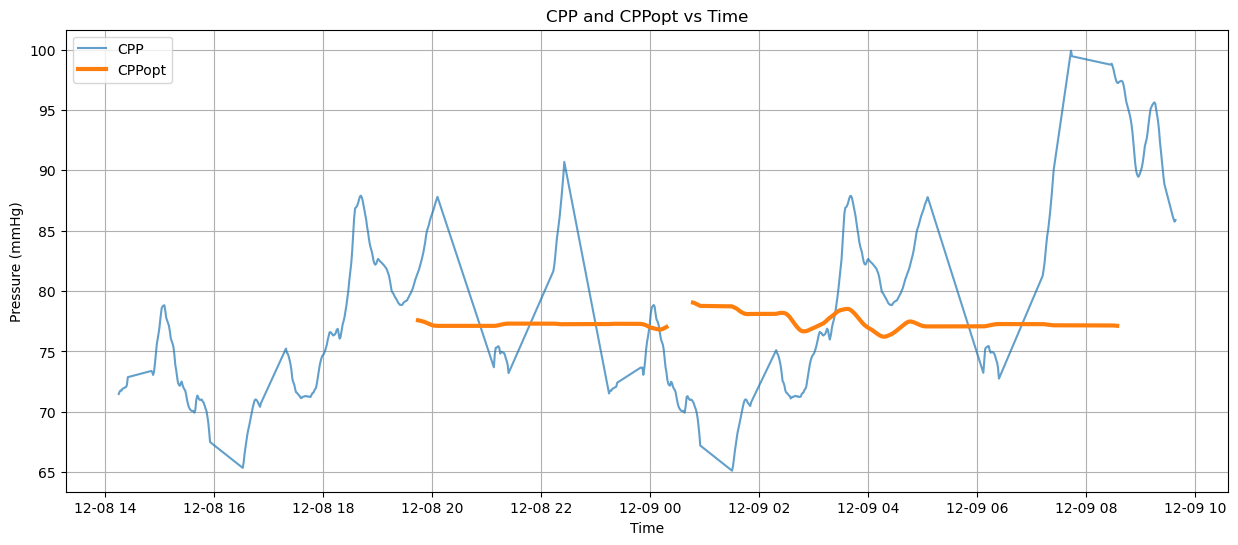

In [14]:
# ============================================================
# CPP AND CPPopt ON SAME GRAPH
# ============================================================

plt.figure(figsize=(15,6))

# ------------------------------------------------------------
# CPP TREND
# ------------------------------------------------------------

plt.plot(
    prx_df['Time'],
    prx_df['Mean_CPP'],
    label='CPP',
    alpha=0.7
)

# ------------------------------------------------------------
# CPPopt TREND
# ------------------------------------------------------------

plt.plot(
    cppopt_df['Time'],
    cppopt_df['CPPopt_Smooth'],
    linewidth=3,
    label='CPPopt'
)

# ------------------------------------------------------------
# GRAPH SETTINGS
# ------------------------------------------------------------

plt.xlabel("Time")
plt.ylabel("Pressure (mmHg)")
plt.title("CPP and CPPopt vs Time")

plt.grid(True)
plt.legend()

plt.show()

In [15]:
# ============================================================
# CREATE CPP DATAFRAME FROM PRx DATA
# ============================================================

cpp_df = prx_df[['Time','Mean_CPP']].copy()

cpp_df.rename(
    columns={'Mean_CPP':'CPP'},
    inplace=True
)

# ============================================================
# MERGE CPP WITH CPPopt
# ============================================================

merged_df = pd.merge_asof(

    cpp_df.sort_values('Time'),

    cppopt_df[['Time','CPPopt']].sort_values('Time'),

    on='Time',

    direction='nearest'

)

# ============================================================
# DIFFERENCE
# ============================================================

merged_df['CPP_Diff'] = (

    merged_df['CPP']

    - merged_df['CPPopt']

)

print(merged_df.head())

                 Time        CPP     CPPopt  CPP_Diff
0 2016-12-08 14:14:53  71.476852  77.583484 -6.106632
1 2016-12-08 14:15:53  71.667593  77.583484 -5.915892
2 2016-12-08 14:16:53  71.766667  77.583484 -5.816818
3 2016-12-08 14:17:53  71.755093  77.583484 -5.828392
4 2016-12-08 14:18:53  71.893519  77.583484 -5.689966


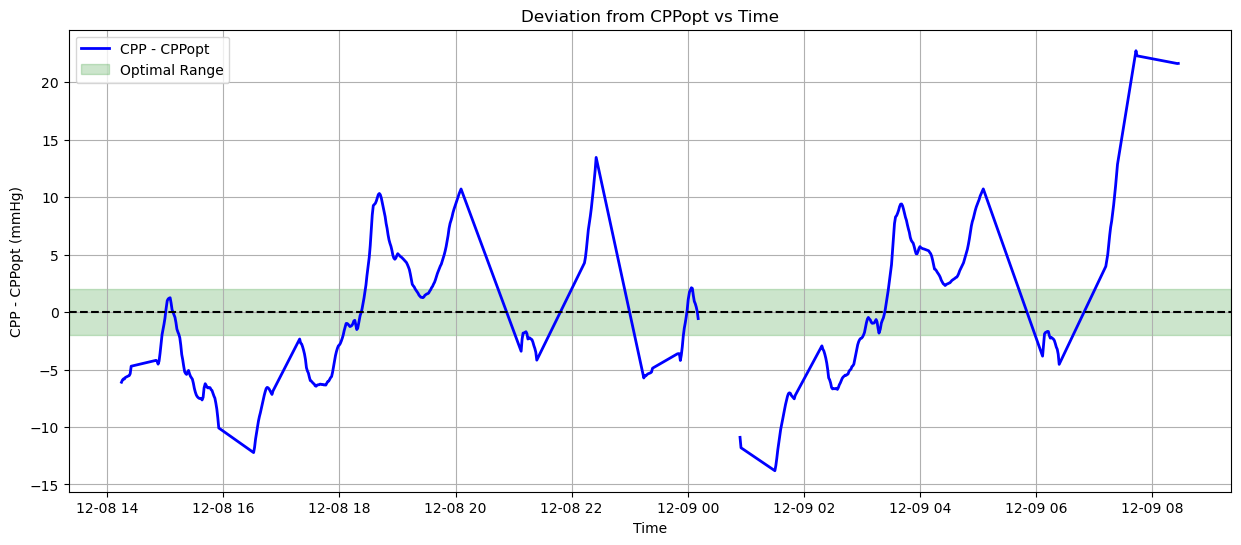

In [16]:
# ============================================================
# PLOT ΔCPP VS TIME
# ============================================================

plt.figure(figsize=(15,6))

# Full trend in light gray

plt.plot(
    merged_df['Time'],
    merged_df['CPP_Diff'],
    color='blue',
    linewidth=2,
    label='CPP - CPPopt'
)

# ============================================================
# GREEN WHERE WITHIN ±2 mmHg
# ============================================================

optimal_mask = (
    merged_df['CPP_Diff'].abs() <= 2
)


# ============================================================
# SHADE OPTIMAL ZONE
# ============================================================

plt.axhspan(
    -2,
    2,
    alpha=0.2,
    color='green',
    label='Optimal Range'
)

# ============================================================
# REFERENCE LINE
# ============================================================

plt.axhline(
    0,
    linestyle='--',
    color='black',
    linewidth=1.5
)

# ============================================================
# LABELS
# ============================================================

plt.xlabel("Time")
plt.ylabel("CPP - CPPopt (mmHg)")
plt.title("Deviation from CPPopt vs Time")

plt.grid(True)
plt.legend()

plt.show()


========== CPP DEVIATION SUMMARY ==========

≤ 2 mmHg     : 19.30%
2–10 mmHg    : 74.26%
10–20 mmHg   : 5.70%
20–30 mmHg   : 0.74%
30–40 mmHg   : 0.00%
> 40 mmHg    : 0.00%


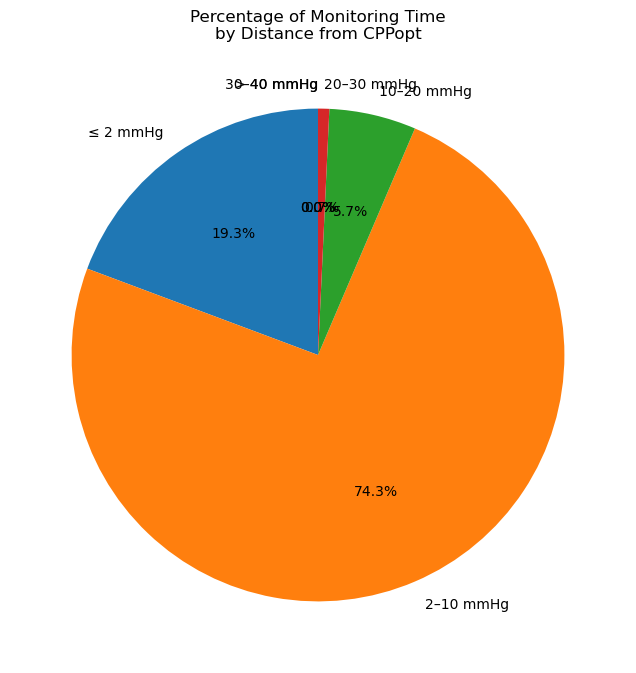

In [17]:
# ============================================================
# ABSOLUTE CPP DEVIATION
# ============================================================

merged_df['Abs_CPP_Diff'] = merged_df['CPP_Diff'].abs()

# ============================================================
# CATEGORIES
# ============================================================

labels = [
    '≤ 2 mmHg',
    '2–10 mmHg',
    '10–20 mmHg',
    '20–30 mmHg',
    '30–40 mmHg',
    '> 40 mmHg'
]

counts = [

    (merged_df['Abs_CPP_Diff'] <= 2).sum(),

    ((merged_df['Abs_CPP_Diff'] > 2) &
     (merged_df['Abs_CPP_Diff'] <= 10)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 10) &
     (merged_df['Abs_CPP_Diff'] <= 20)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 20) &
     (merged_df['Abs_CPP_Diff'] <= 30)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 30) &
     (merged_df['Abs_CPP_Diff'] <= 40)).sum(),

    (merged_df['Abs_CPP_Diff'] > 40).sum()

]

# ============================================================
# PRINT PERCENTAGES
# ============================================================

total = sum(counts)

print("\n========== CPP DEVIATION SUMMARY ==========\n")

for label, count in zip(labels, counts):

    percent = 100 * count / total

    print(f"{label:12s} : {percent:.2f}%")

# ============================================================
# PIE CHART
# ============================================================

plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Percentage of Monitoring Time\nby Distance from CPPopt'
)

plt.show()

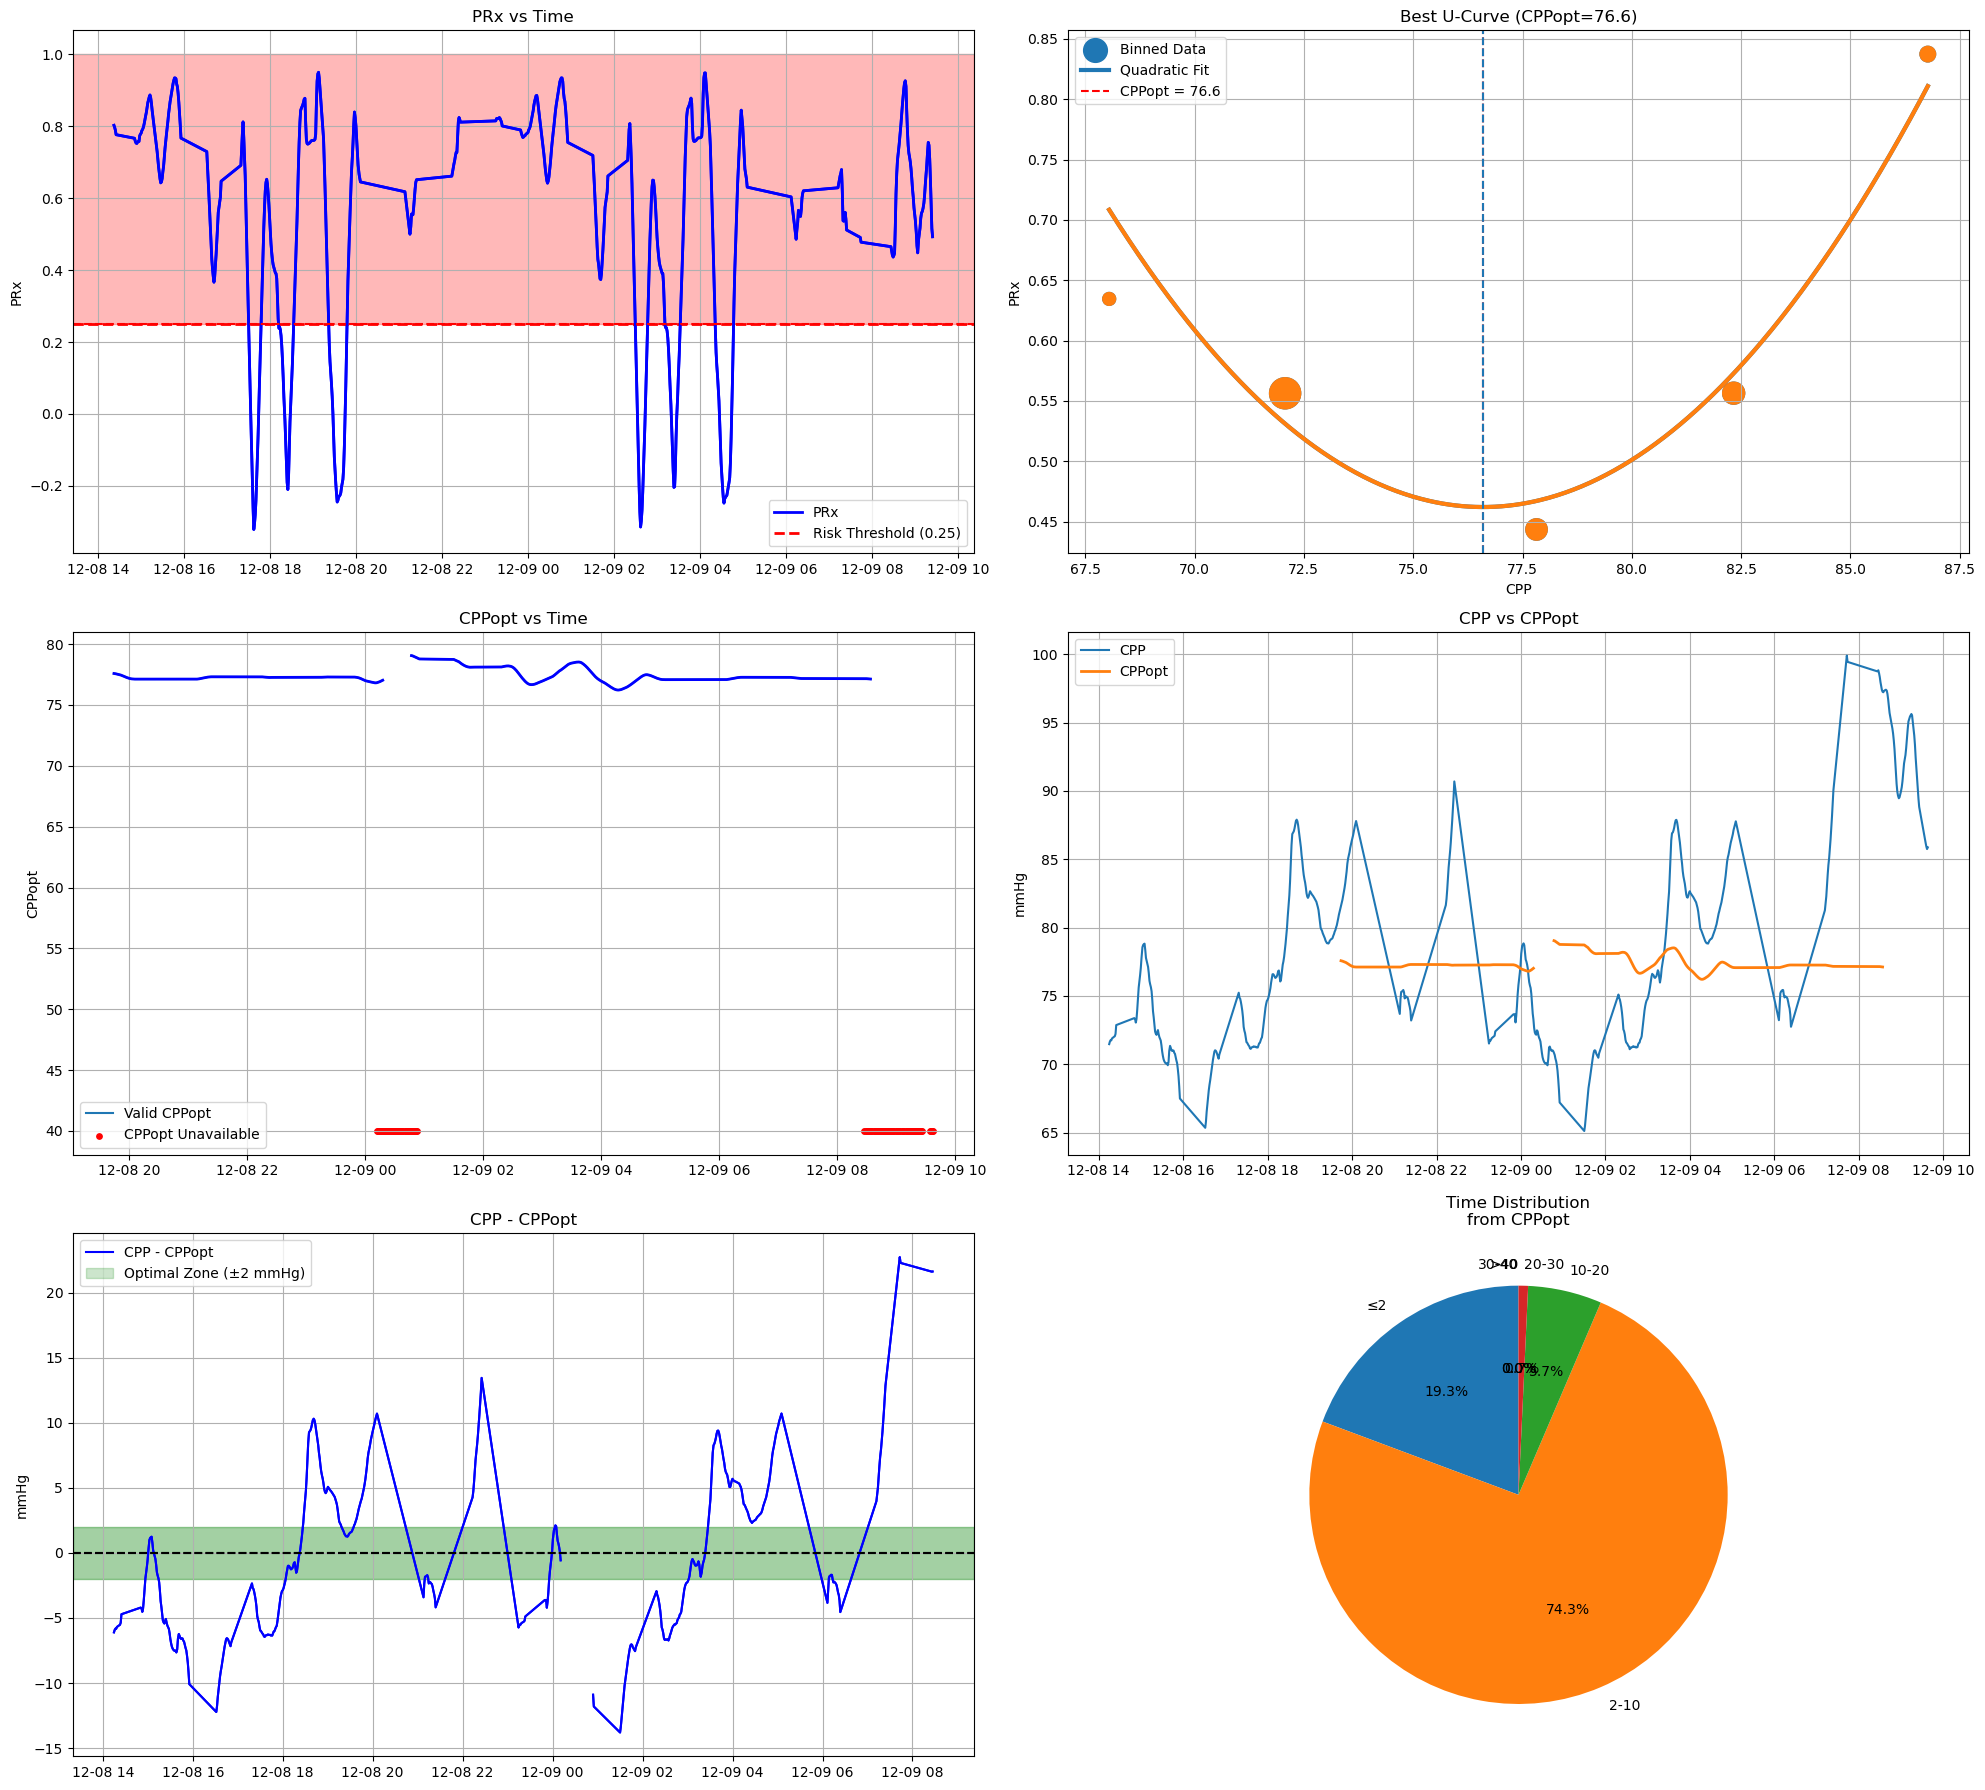

In [26]:
# ============================================================
# FINAL DASHBOARD (ALL RESULTS TOGETHER)
# ============================================================

fig, axs = plt.subplots(3, 2, figsize=(20, 18))
ax1 = axs[0,0]
ax2 = axs[0,1]
ax3 = axs[1,0]
ax4 = axs[1,1]
ax5 = axs[2,0]

# ============================================================
# 1. PRx vs Time
# ============================================================
ax1.plot(
    prx_df['Time'],
    prx_df['PRx_Smooth'],
    color='blue',
    linewidth=2,
    label='PRx'
)

ax1.axhline(
    y=0.25,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Risk Threshold (0.25)'
)

ax1.axhspan(
    0.25,
    1.0,
    color='red',
    alpha=0.15
)

ax1.legend()

axs[0,0].plot(
    prx_df['Time'],
    prx_df['PRx_Smooth'],
    color='blue',
    linewidth=2
)

axs[0,0].axhline(
    y=0.25,
    color='red',
    linestyle='--'
)

axs[0,0].axhspan(
    0.25,
    1.0,
    color='red',
    alpha=0.15
)

axs[0,0].set_title("PRx vs Time")
axs[0,0].set_ylabel("PRx")
axs[0,0].grid(True)

# ============================================================
# 2. Best U Curve
# ============================================================
ax2.scatter(
    x,
    y,
    s=w*5,
    label='Binned Data'
)

ax2.plot(
    x_fit,
    y_fit,
    linewidth=3,
    label='Quadratic Fit'
)

ax2.axvline(
    best_cppopt,
    linestyle='--',
    color='red',
    label=f'CPPopt = {best_cppopt:.1f}'
)

ax2.legend()

a, b, c = best_params

x = best_grouped['Mean_CPP'].values
y = best_grouped['Mean_PRx'].values
w = best_grouped['Count'].values

x_fit = np.linspace(min(x), max(x), 500)
y_fit = quadratic(x_fit, a, b, c)

axs[0,1].scatter(
    x,
    y,
    s=w*5
)

axs[0,1].plot(
    x_fit,
    y_fit,
    linewidth=3
)

axs[0,1].axvline(
    best_cppopt,
    linestyle='--'
)

axs[0,1].set_title(
    f'Best U-Curve (CPPopt={best_cppopt:.1f})'
)

axs[0,1].set_xlabel("CPP")
axs[0,1].set_ylabel("PRx")
axs[0,1].grid(True)

# ============================================================
# 3. CPPopt vs Time
# ============================================================
ax3.plot(
    cppopt_df['Time'],
    cppopt_df['CPPopt_Smooth'],
    label='Valid CPPopt'
)

ax3.scatter(
    rejected_df['Time'],
    np.full(len(rejected_df),40),
    color='red',
    s=15,
    label='CPPopt Unavailable'
)

ax3.legend()

axs[1,0].plot(
    cppopt_df['Time'],
    cppopt_df['CPPopt_Smooth'],
    color='blue',
    linewidth=2
)

axs[1,0].scatter(
    rejected_df['Time'],
    np.full(len(rejected_df),40),
    color='red',
    s=10
)

axs[1,0].set_title("CPPopt vs Time")
axs[1,0].set_ylabel("CPPopt")
axs[1,0].grid(True)

# ============================================================
# 4. CPP and CPPopt
# ============================================================

axs[1,1].plot(
    prx_df['Time'],
    prx_df['Mean_CPP'],
    label='CPP'
)

axs[1,1].plot(
    cppopt_df['Time'],
    cppopt_df['CPPopt_Smooth'],
    linewidth=2,
    label='CPPopt'
)

axs[1,1].set_title("CPP vs CPPopt")
axs[1,1].set_ylabel("mmHg")
axs[1,1].legend()
axs[1,1].grid(True)

# ============================================================
# 5. CPP Deviation
# ============================================================
ax5.plot(
    merged_df['Time'],
    merged_df['CPP_Diff'],
    color='blue',
    label='CPP - CPPopt'
)

ax5.axhspan(
    -2,
    2,
    color='green',
    alpha=0.2,
    label='Optimal Zone (±2 mmHg)'
)

ax5.axhline(
    0,
    color='black',
    linestyle='--'
)

ax5.legend()

axs[2,0].plot(
    merged_df['Time'],
    merged_df['CPP_Diff'],
    color='blue'
)

axs[2,0].axhspan(
    -2,
    2,
    color='green',
    alpha=0.2
)

axs[2,0].axhline(
    0,
    linestyle='--',
    color='black'
)

axs[2,0].set_title("CPP - CPPopt")
axs[2,0].set_ylabel("mmHg")
axs[2,0].grid(True)

# ============================================================
# 6. Pie Chart
# ============================================================
labels = [
    '≤2',
    '2-10',
    '10-20',
    '20-30',
    '30-40',
    '>40'
]

counts = [

    (merged_df['Abs_CPP_Diff'] <= 2).sum(),

    ((merged_df['Abs_CPP_Diff'] > 2) &
     (merged_df['Abs_CPP_Diff'] <= 10)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 10) &
     (merged_df['Abs_CPP_Diff'] <= 20)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 20) &
     (merged_df['Abs_CPP_Diff'] <= 30)).sum(),

    ((merged_df['Abs_CPP_Diff'] > 30) &
     (merged_df['Abs_CPP_Diff'] <= 40)).sum(),

    (merged_df['Abs_CPP_Diff'] > 40).sum()

]

axs[2,1].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

axs[2,1].set_title(
    'Time Distribution\nfrom CPPopt'
)

# ============================================================
# FINISH
# ============================================================

plt.tight_layout()

plt.savefig(
    "Cerebral_Monitoring_Dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()